# Bitcoin Persistence-Enhanced Log-Return LSTM

## Role
Final supervised recurrent-model evidence.

## Inputs
Frozen PE-LSTM and validated forecast artifacts.

## Outputs
Artifact-derived PE-LSTM metrics and reproducibility record.

## Depends On
01 Bitcoin Data/EDA.

## Authoritative Status
AUTHORITATIVE MODEL ANALYSIS

## What This Notebook Does Not Do
Safe Run All does not train TensorFlow or overwrite the frozen vector.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


## Authoritative design
A 30-return input window predicts a scaled log return. A train-only scaler is used; the predicted return is reconstructed from the previous observed price. Generation used seed 42, deterministic TensorFlow, `shuffle=False`, and chronological validation.

In [2]:
# Load the canonical split and frozen PE-LSTM forecast.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

# Compute and display the unchanged PE-LSTM metrics.
metric_table(
    validated.Actual,
    {'Persistence-Enhanced Log-Return LSTM': validated.Persistence_Enhanced_LSTM},
    train,
)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Persistence-Enhanced Log-Return LSTM,1321.365311,1881.09119,1.783956,1.791645,4.685603,1061


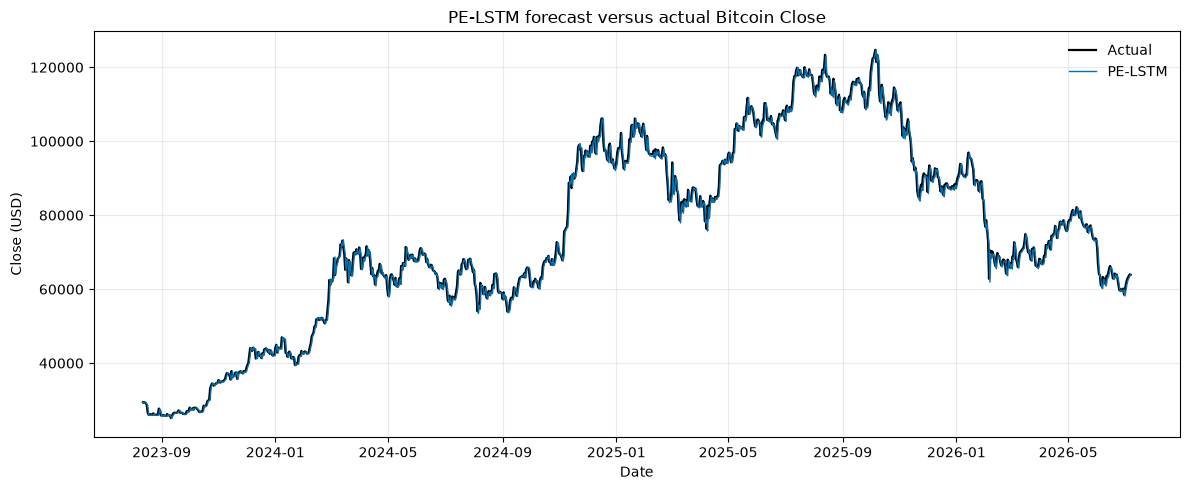

In [3]:
import matplotlib.pyplot as plt

# Compare the frozen PE-LSTM forecast with held-out actual prices.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Persistence_Enhanced_LSTM, color='#0072B2', linewidth=1.0, label='PE-LSTM')
ax.set(title='PE-LSTM forecast versus actual Bitcoin Close', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Determinism evidence
External fresh-kernel regression checks previously produced bit-identical forecasts; the independent run vectors were not preserved as separate authoritative artifacts. No three-run plot is presented.

## Historical provenance
Raw-price LSTM variants were development experiments and are excluded from every final table, figure, Trust Score, and inference test.